 ## Data Visualization & Binding Affinity Analysis
This notebook serves as the quantitative analysis and visualization hub of the pipeline. Following the completion of the AutoDock Vina simulations, this script automatically parses the raw docking logs, extracts the optimal binding energies, and generates high-resolution, publication-ready visual assets. This allows for a rapid, comparative assessment of all screened ligands to identify the most thermodynamically favorable drug candidates.
## Workflow & Methodology

### Automated Log Parsing:
Scans the docking_results directory and opens each Vina-generated _log.txt file. It programmatically extracts the binding affinity (in kcal/mol) of the top-ranked conformational pose (Pose 1) for every ligand.
### Data Aggregation & Sorting:
Compiles the extracted scores into a structured Pandas DataFrame, automatically sorting the ligands from most negative (strongest binding) to least negative (weakest binding).
### Data Export:
Saves the sorted binding affinity data as a clear, tabular .csv file, making it easy to integrate into the final manuscript's results section.
### 2D Visualization:
Utilizes Matplotlib to generate a comparative bar chart of the docking scores. The plot is customized with academic formatting (labels, grids, and proper scaling).
### High-Resolution Rendering:
Exports the final bar chart as a 300 DPI .png image, meeting standard publisher requirements for scientific figures.

### Dependencies

Python Libraries:
-pandas (Data structuring), matplotlib.pyplot (Plotting and image generation), os, glob, google.colab.drive.


In [1]:
!pip install pandas matplotlib py3Dmol

Connecting to Google Drive...
Mounted at /content/drive

--- Starting Data Extraction ---
✅ Data extracted and saved to: /content/drive/MyDrive/Docking_Pipeline/analysis_results/binding_affinities_summary.csv

Summary Table:
  Ligand_CID  Binding_Affinity_kcal_mol
0    5281034                     -9.865
3       5291                     -9.338
4     123631                     -9.207
2       3672                     -6.765
1       2244                     -5.913

--- Generating Publication Plot ---
✅ High-resolution plot saved to: /content/drive/MyDrive/Docking_Pipeline/analysis_results/binding_affinities_plot.png


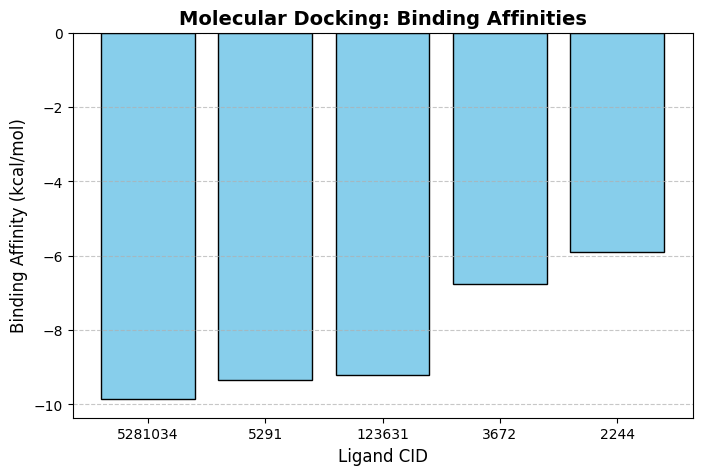


--- Pipeline Complete! ---


In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import py3Dmol
from google.colab import drive

# --- 1. Mount Google Drive ---
print("Connecting to Google Drive...")
drive.mount('/content/drive', force_remount=True)

# --- 2. Define Paths ---
BASE_DIR = "/content/drive/MyDrive/Docking_Pipeline"
RESULTS_DIR = os.path.join(BASE_DIR, "docking_results")
ANALYSIS_DIR = os.path.join(BASE_DIR, "analysis_results")
os.makedirs(ANALYSIS_DIR, exist_ok=True)

print("\n--- Starting Data Extraction ---")

# --- 3. Extract Binding Affinities ---
log_files = glob.glob(os.path.join(RESULTS_DIR, "*_log.txt"))
results_data = []

for log in log_files:
    ligand_name = os.path.basename(log).replace("_3D_log.txt", "").replace("ligand_", "")

    with open(log, 'r') as f:
        lines = f.readlines()
        for line in lines:
            # The top pose is always listed as '1' in the Vina log table
            if line.strip().startswith('1'):
                parts = line.split()
                affinity = float(parts[1]) # The second column is the energy score
                results_data.append({"Ligand_CID": ligand_name, "Binding_Affinity_kcal_mol": affinity})
                break # We only need the top score

# Create a DataFrame and save to CSV
df = pd.DataFrame(results_data)
# Sort by best score (lowest energy)
df = df.sort_values(by="Binding_Affinity_kcal_mol")
csv_path = os.path.join(ANALYSIS_DIR, "binding_affinities_summary.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Data extracted and saved to: {csv_path}")
print("\nSummary Table:")
print(df)

# --- 4. Generate 2D Bar Chart (PNG for Manuscript) ---
print("\n--- Generating Publication Plot ---")
plt.figure(figsize=(8, 5))
plt.bar(df["Ligand_CID"], df["Binding_Affinity_kcal_mol"], color='skyblue', edgecolor='black')
plt.title("Molecular Docking: Binding Affinities", fontsize=14, fontweight='bold')
plt.xlabel("Ligand CID", fontsize=12)
plt.ylabel("Binding Affinity (kcal/mol)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save as high-res PNG
png_path = os.path.join(ANALYSIS_DIR, "binding_affinities_plot.png")
plt.savefig(png_path, dpi=300, bbox_inches='tight')
print(f"✅ High-resolution plot saved to: {png_path}")
plt.show()

print("\n--- Pipeline Complete! ---")